# Astrometric epoch propagation

This notebook demonstrates how to improve crossmatches between LSST DP2 objects and Gaia DR3 by accounting for stellar motion over time (epoch propagation).

Epoch propagation updates a source’s sky position from one observation epoch to another using its proper motion (and, when available, parallax and radial velocity). This should not be confused with the Equinox of the coordinate system: both catalogs use the ICRS frame with Equinox J2000.

Run this notebook on the Rubin Science Platform (or another environment where DP2 is available and LSDB is pre-installed). For DP2 access details, see: https://lsdb.io/dp2

We will:

- Set up the environment and define epochs for DP2 and Gaia DR3.
- Open the relevant catalogs and compute a safe search radius.
- Propagate Gaia source coordinates from the Gaia epoch to the DP2 epoch.
- Crossmatch DP2 objects with the propagated Gaia positions and select the best matches.
- Compare against a baseline crossmatch that does not use propagation.
- Visualize the difference between the two approaches.

In [ ]:
#%pip install git+https://github.com/astronomy-commons/lsdb.git@sean/map_parts_align

In [1]:
import lsdb
import numpy as np
from astropy import units
from astropy.coordinates import Distance, SkyCoord
from astropy.time import Time
from dask.distributed import Client
from upath import UPath

In [ ]:
print(f"{lsdb.__version__ = }")

lsdb.__version__ = '0.8.3.dev7+g61d473f8c'


## 1. Define epochs

We specify the observation epochs for LSST DP2 (mid 2025) and Gaia DR3 (2016.0). These are used to translate Gaia source positions from the Gaia epoch to the DP2 epoch.

In [3]:
# DP2 was mostly captured between June-September 2025. 
# We use an approximate value of early August for simplicity.
dp2_epoch = 2025.6
# https://gaia.aip.de/metadata/gaiadr3/
gaia_dr3_epoch = 2016.0

## 2. Open catalogs and gather configuration

Open the DP2 object catalog and retrieve its matching margin. This margin helps us decide how far to search around each DP2 source when looking for Gaia counterparts.
Here we use Rubin Science Platform path to DP2, please adjust as needed; see https://lsdb.io/dp2 for details.

In [4]:
base_path = UPath("/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2")
# We select the positional columns only
dp2_object = lsdb.open_catalog(base_path / 'object_collection', columns=["coord_ra","coord_dec"])
dp2_margin_arcsec = dp2_object.margin.hc_structure.catalog_info.margin_threshold

## 3. Derive a proper-motion filter

Compute a maximum allowed proper motion based on the DP2 margin and the time difference between the two epochs. This helps us restrict Gaia sources to those that could plausibly still fall within the DP2 search area after propagation. Gaia proper motions are in marcsec/year, hence the multiplication by 1000.

In [5]:
max_pm = 1000.0 * dp2_margin_arcsec / (dp2_epoch - gaia_dr3_epoch)
max_pm

520.8333333333383

## 4. Load a filtered Gaia DR3 subset

Open a Gaia DR3 catalog with the columns needed for propagation and filter out entries lacking required motion or distance information. For S3 access we use MAST’s open buckets; see https://data.lsdb.io/#Gaia/Gaia_DR3_(US-East,_S3) for details.

In [6]:
gaia_dr3 = lsdb.open_catalog(
    "s3://stpubdata/gaia/gaia_dr3/public/hats",
    columns=["pmra", "pmdec", "radial_velocity", "parallax"],
    filters=[("pm", "<", max_pm), ("parallax", ">", 0.0)],
).query("radial_velocity.notna()")

## 5. Define epoch propagation

Create a helper that takes Gaia source attributes at the Gaia epoch and computes their positions at the DP2 epoch. We leverage Astropy to carry out the space‑motion propagation.

**Important**: Notice how we do not update the catalog ra/dec columns in place. That is an illegal action that would break the structure of the HATS catalog (e.g. _healpix_29), as well as margins, which are needed in the next step of crossmatch! To prevent this from happening we create new columns, "ra_corr" and "dec_corr", to store the propagated positions.

In [10]:
def propagate_epoch(df, *, start, end):
    if len(df) == 0:
        col_type = np.array([], dtype=float)
        return df[["ra","dec"]].assign(ra_corr=col_type, dec_corr=col_type)
        
    start_coord = SkyCoord(
        ra=df["ra"].to_numpy() * units.deg,
        dec=df["dec"].to_numpy() * units.deg,
        pm_ra_cosdec=df["pmra"].to_numpy() * units.marcsec / units.year,
        pm_dec=df["pmdec"].to_numpy() * units.marcsec / units.year,
        radial_velocity=df["radial_velocity"].to_numpy() * units.km / units.s,
        distance=Distance(parallax=df["parallax"].to_numpy() * units.marcsec),
        # Besselian year format, used by Gaia
        obstime=Time(start, format="byear"),
        frame="icrs",
    )
    end_coord = start_coord.apply_space_motion(new_obstime=Time(end, format="byear"))
    df["ra_corr"] = end_coord.ra.deg
    df["dec_corr"] = end_coord.dec.deg

    # Return only the columns we need going forward
    return df[["ra","dec","ra_corr","dec_corr"]]

propagated_gaia = gaia_dr3.map_partitions(propagate_epoch, start=gaia_dr3_epoch, end=dp2_epoch)
propagated_gaia

,ra,dec,ra_corr,dec_corr
npartitions=2016,,,,
"Order: 2, Pixel: 0",double[pyarrow],double[pyarrow],float64,float64
"Order: 2, Pixel: 1",...,...,...,...
...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...


## 6. Crossmatch propagated Gaia to DP2 and select the best match

This is a two‑step crossmatching pipeline:

- We search with the largest radius that still preserves correct matches — the DP2 catalog’s margin defines this “safe” maximum. Using this margin ensures candidates that truly belong together are not missed.
- We intentionally keep multiple nearby Gaia candidates per DP2 object at first. After that, we compare candidates and choose the single best one using their separation. This approach lets us propagate to the target epoch and then make an informed choice among several plausible neighbors.

In [15]:
xmatch = dp2_object.crossmatch_nested(propagated_gaia, radius_arcsec=dp2_margin_arcsec, n_neighbors=20)
xmatch

,coord_ra,coord_dec,gaia
npartitions=19729,,,
"Order: 6, Pixel: 17034",double[pyarrow],double[pyarrow],"nested<ra: [double], dec: [double], ra_corr: [..."
"Order: 6, Pixel: 17035",...,...,...
...,...,...,...
"Order: 8, Pixel: 784420",...,...,...
"Order: 7, Pixel: 196106",...,...,...


Let's save the crossmatch catalog to disk:

In [ ]:
# This step is crucial to ensure a smaller, more tractable
# Dask task graph size after the upcoming `best_matches` step.
with Client(n_workers=64, memory_limit="4GiB", threads_per_worker=1):
    xmatch.write_catalog("object_lc_x_gaia", as_collection=False)

Now that we have the catalog on disk, let's re-read it. This step helps reduce the size of the Dask task graph.

In [ ]:
xmatch = lsdb.open_catalog("object_lc_x_gaia")
# Filter out objects with no matches
xmatch = xmatch[~xmatch["gaia"].isna()]
xmatch

,coord_ra,coord_dec,gaia
npartitions=19729,,,
"Order: 6, Pixel: 17034",double[pyarrow],double[pyarrow],"nested<ra: [double], dec: [double], ra_corr: [..."
"Order: 6, Pixel: 17035",...,...,...
...,...,...,...
"Order: 8, Pixel: 784420",...,...,...
"Order: 7, Pixel: 196106",...,...,...


For each DP2 object, we then choose the closest propagated Gaia candidate within a small tolerance. This reduces multiple candidates to a single best match when possible.

In [22]:
def select_best_match(dp2_ra, dp2_dec, gaia_ra, gaia_dec, *, max_dist_arcsec):
    dp2_coord = SkyCoord(ra=dp2_ra * units.deg, dec=dp2_dec * units.deg)
    gaia_coord = SkyCoord(ra=gaia_ra * units.deg, dec=gaia_dec * units.deg)
    distance = gaia_coord.separation(dp2_coord)
    idx_close = np.where(distance < max_dist_arcsec * units.arcsec)[0]
    if len(idx_close) == 0:
        return {"gaia_ra_corr": np.nan, "gaia_dec_corr": np.nan, "distance": np.nan}
    best_idx = min(idx_close, key=distance.__getitem__)
    return {
        "gaia_ra_corr": gaia_ra[best_idx],
        "gaia_dec_corr": gaia_dec[best_idx],
        "distance": distance[best_idx].to_value(units.arcsec),
    }

best_matches = (
    xmatch.map_rows(
        select_best_match,
        columns=["coord_ra", "coord_dec", "gaia.ra_corr", "gaia.dec_corr"],
        max_dist_arcsec=0.1,
        append_columns=True,
        row_container="args",
        meta=dict.fromkeys(["gaia_ra_corr", "gaia_dec_corr", "distance"], float),
    )
    .map_partitions(lambda df: df.drop(columns=["gaia"]))
    .query("distance.notna()")
)
best_matches

,coord_ra,coord_dec,gaia_ra_corr,gaia_dec_corr,distance
npartitions=19729,,,,,
"Order: 6, Pixel: 17034",double[pyarrow],double[pyarrow],float64,float64,float64
"Order: 6, Pixel: 17035",...,...,...,...,...
...,...,...,...,...,...
"Order: 8, Pixel: 784420",...,...,...,...,...
"Order: 7, Pixel: 196106",...,...,...,...,...


## 7. Baseline: crossmatch without propagation

As a point of comparison, perform a standard positional crossmatch using the Gaia positions at their original epoch (no propagation).

In [ ]:
naive_matches = dp2_object.crossmatch(gaia_dr3, radius_arcsec=0.1, suffix_method="overlapping_columns")
# Filter out objects with no matches
naive_matches = naive_matches[~naive_matches["_dist_arcsec"].isna()]
naive_matches

,coord_ra,coord_dec,pmra,pmdec,radial_velocity,parallax,ra,dec,_dist_arcsec
npartitions=19729,,,,,,,,,
"Order: 6, Pixel: 17034",double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 6, Pixel: 17035",...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...
"Order: 8, Pixel: 784420",...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 196106",...,...,...,...,...,...,...,...,...


## 8. Compute results with a local Dask client

All steps above are lazily evaluated. Here we actually run both pipelines — with propagation and without — and collect the results into Pandas DataFrames. We also print the number of matches from each pipeline.

In [ ]:
with Client(n_workers=64, memory_limit="4GiB", threads_per_worker=1) as client:
    best_matches_df = best_matches[["distance"]].compute()
    print(f"Propagated matches: {len(best_matches_df)}")

/sdf/home/s/stavar/.local/lib/python3.13/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 22.85 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Propagated matches: 290751


,distance
_healpix_29,
1198707046169645354,0.011167
1198707499051007110,0.004882
...,...
3449943055862504482,0.015517
3449944245686055172,0.013712


In [ ]:
with Client(n_workers=64, memory_limit="4GiB", threads_per_worker=1) as client:
    naive_matches_df = naive_matches[["_dist_arcsec"]].compute()
    print(f"Non-propagated matches: {len(naive_matches_df)}")

/sdf/home/s/stavar/.local/lib/python3.13/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 57.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/sdf/home/s/stavar/.local/lib/python3.13/site-packages/fsspec/caching.py:692: UserWarning: Read is outside the known file parts: (14142571, 16867339). IO/caching performance may be poor!
  warnings.warn(
/sdf/home/s/stavar/.local/lib/python3.13/site-packages/fsspec/caching.py:692: UserWarning: Read is outside the known file parts: (189105962, 191826505). IO/caching performance may be poor!
  warnings.warn(
/sdf/home/s/stavar/.local/lib/python3.13/site-packages/fsspec/caching.py:692: UserWarning: Read is outside the known file parts: (14892392, 17502882). IO/caching performa

Non-propagated matches: 195251


,_dist_arcsec
_healpix_29,
2041030883055994636,0.056021
2042748375243450012,0.027974
...,...
3434715952770358012,0.062528
3434744985706509067,0.050126


## 9. Plot separation distribution

Plot histograms of match separations for both approaches and highlight the effect of propagation. In this run, the propagated pipeline yields more matches (290,751 vs 192,251), and the separation distribution is tighter (more matches at smaller separations).

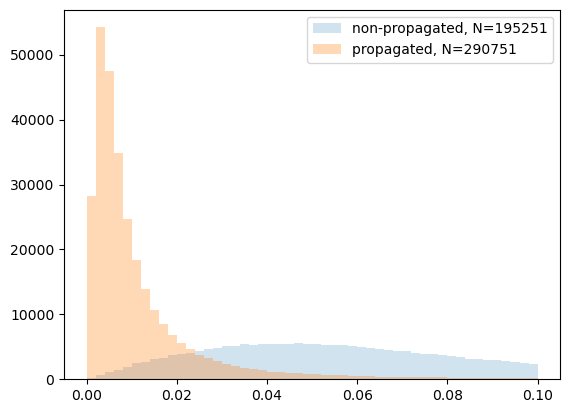

In [25]:
import matplotlib.pyplot as plt

plt.hist(
    naive_matches_df["_dist_arcsec"],
    bins=np.linspace(0, 0.1, 51),
    histtype="stepfilled",
    alpha=0.2,
    label=f"non-propagated, N={len(naive_matches_df)}",
)
plt.hist(
    best_matches_df["distance"],
    bins=np.linspace(0, 0.1, 51),
    histtype="stepfilled",
    alpha=0.3,
    label=f"propagated, N={len(best_matches_df)}",
)
plt.legend()

The median value is ~7.5x smaller for the propagated distance distribution:

In [41]:
propagated_median = np.median(best_matches_df["distance"])
print("Propagated median:", propagated_median)

Propagated median: 0.006804304323108497


In [ ]:
naive_median = np.median(naive_matches_df["_dist_arcsec"])
print("Naive median:", naive_median)

Naive median: 0.05058704390345909
